## MUSE training

In [ ]:
import os
import random
import gzip
from pathlib import Path

import numpy as np
import torch
import scanpy as sc
import museclue
import networkx as nx
import anndata as ad
import matplotlib as mpl
import matplotlib.pyplot as plt

def set_seed(seed: int = 1234) -> None:
    """Set random seeds for reproducibility (Python / NumPy / PyTorch / CUDA)."""
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"[INFO] Random seed set to {seed}")


set_seed(1234)

In [4]:
# ---------
# Paths
# ---------
DATA_DIR = Path("/home/nkefk/MUSE/data")
GRAPH_PATH = Path("/home/nkefk/MUSE/graph/macaque_mouse.guidance.graphml.gz")

OUT_DIR = Path("/home/nkefk/MUSE/trained_model")
OUT_DIR.mkdir(parents=True, exist_ok=True)

RUN_DIR = Path("macaque_mouse_muse")  # training logs/checkpoints
MODEL_PATH = OUT_DIR / "macaque_mouse_muse_model.dill"

# ---------
# Inputs
# ---------
MACAQUE_RNA_PATH  = DATA_DIR / "A82B_macaque_pp_rna_1852genes_with_protein_embedding.h5ad"
MACAQUE_ATAC_PATH = DATA_DIR / "A82B_macaque_pp_atac_25087peaks.h5ad"
MOUSE_RNA_PATH    = DATA_DIR / "E145_2_mouse_pp_rna_2141genes_with_protein_embedding.h5ad"
MOUSE_ATAC_PATH   = DATA_DIR / "E145_2_mouse_pp_atac_20985peaks.h5ad"

In [7]:
def load_graphml_gz(path: Path) -> nx.Graph:
    """Load a GraphML graph compressed with gzip (.graphml.gz)."""
    with gzip.open(path, "rb") as f:
        g = nx.read_graphml(f)
    return g


def add_prefix_to_var_names(adata: sc.AnnData, prefix: str) -> None:
    """Prefix var_names in-place to avoid collisions across species."""
    adata.var_names = [f"{prefix}_{v}" for v in adata.var_names]


def configure_for_scglue_rna(adata: sc.AnnData) -> None:
    museclue.models.configure_dataset(
        adata,
        prob_model="NB",
        use_highly_variable=False,
        use_layer="counts",
        use_rep="X_pca",
        use_obs_names=True,
    )


def configure_for_scglue_atac(adata: sc.AnnData) -> None:
    museclue.models.configure_dataset(
        adata,
        prob_model="NB",
        use_highly_variable=False,
        use_rep="X_lsi",
        use_obs_names=True,
    )

In [8]:
# -------------
# Load datasets
# -------------
macaque_rna = sc.read_h5ad(MACAQUE_RNA_PATH)
macaque_atac = sc.read_h5ad(MACAQUE_ATAC_PATH)
mouse_rna = sc.read_h5ad(MOUSE_RNA_PATH)
mouse_atac = sc.read_h5ad(MOUSE_ATAC_PATH)

# Prefix var_names to ensure uniqueness across species
add_prefix_to_var_names(macaque_rna, "macaque")
add_prefix_to_var_names(macaque_atac, "macaque")
add_prefix_to_var_names(mouse_rna, "mouse")
add_prefix_to_var_names(mouse_atac, "mouse")

print("[INFO] Loaded AnnData objects:")
print("  macaque_rna :", macaque_rna.shape)
print("  macaque_atac:", macaque_atac.shape)
print("  mouse_rna   :", mouse_rna.shape)
print("  mouse_atac  :", mouse_atac.shape)

[INFO] Loaded AnnData objects:
  macaque_rna : (12194, 1852)
  macaque_atac: (12194, 25087)
  mouse_rna   : (5702, 2141)
  mouse_atac  : (5702, 20985)


In [ ]:
# ----------------
# Load guidance graph
# ----------------
guidance_graph = load_graphml_gz(GRAPH_PATH)
print(f"[INFO] Guidance graph: nodes={guidance_graph.number_of_nodes():,}, edges={guidance_graph.number_of_edges():,}")

# Optional sanity check
museclue.graph.check_graph(
    guidance_graph,
    [macaque_rna, macaque_atac, mouse_rna, mouse_atac]
)
print("[INFO] Graph check passed.")

In [ ]:
# ----------------
# Configure datasets
# ----------------
configure_for_scglue_rna(macaque_rna)
configure_for_scglue_atac(macaque_atac)
configure_for_scglue_rna(mouse_rna)
configure_for_scglue_atac(mouse_atac)

print("[INFO] Datasets configured for MUSE.")

In [ ]:
# ----------------
# Train MUSE model
# ----------------
muse = museclue.models.fit_SCGLUE(
    {
        "macaque_rna": macaque_rna,
        "macaque_atac": macaque_atac,
        "mouse_rna": mouse_rna,
        "mouse_atac": mouse_atac,
    },
    guidance_graph,
    model=museclue.models.SCGLUEModel,
    fit_kws={"directory": str(RUN_DIR)},
)

print("[INFO] Training finished.")

In [ ]:
# ----------------
# Save model
# ----------------
muse.save(str(MODEL_PATH))
print(f"[INFO] Saved model: {MODEL_PATH}")

## Visualization

In [5]:
trained_model = museclue.models.load_model(MODEL_PATH)

[INFO] autodevice: Using CPU as computation device.


In [10]:
macaque_rna.obsm["X_muse"] = trained_model.encode_data("macaque_rna", macaque_rna)
macaque_atac.obsm["X_muse"] = trained_model.encode_data("macaque_atac", macaque_atac)
mouse_rna.obsm["X_muse"] = trained_model.encode_data("mouse_rna", mouse_rna)
mouse_atac.obsm["X_muse"] = trained_model.encode_data("mouse_atac", mouse_atac)

In [ ]:
macaque_rna.obs["domain"] = "rna"
macaque_atac.obs["domain"] = "atac"
macaque_combined = ad.concat([macaque_rna, macaque_atac])

mouse_rna.obs["domain"] = "rna"
mouse_atac.obs["domain"] = "atac"
mouse_combined = ad.concat([mouse_rna, mouse_atac])

macaque_rna.obs["domain"] = "macaque_rna"
macaque_atac.obs["domain"] = "macaque_atac"
mouse_rna.obs["domain"] = "mouse_rna"
mouse_atac.obs["domain"] = "mouse_atac"
macaque_rna.obs["species"] = "macaque"
macaque_atac.obs["species"] = "macaque"
mouse_rna.obs["species"] = "mouse"
mouse_atac.obs["species"] = "mouse"

all_combined = ad.concat([macaque_rna, macaque_atac, mouse_rna, mouse_atac])

/home/nkefk/miniconda3/envs/muse-dev/lib/python3.10/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/nkefk/miniconda3/envs/muse-dev/lib/python3.10/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/nkefk/miniconda3/envs/muse-dev/lib/python3.10/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/nkefk/miniconda3/envs/muse-dev/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/nkefk/miniconda3/envs/muse-dev/lib/python3.10/site-packages/anndata/_core/anndata.py:121: 

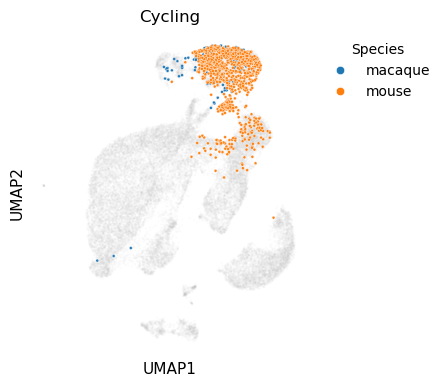

/home/nkefk/miniconda3/envs/muse-dev/lib/python3.10/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/nkefk/miniconda3/envs/muse-dev/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/nkefk/miniconda3/envs/muse-dev/lib/python3.10/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/nkefk/miniconda3/envs/muse-dev/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


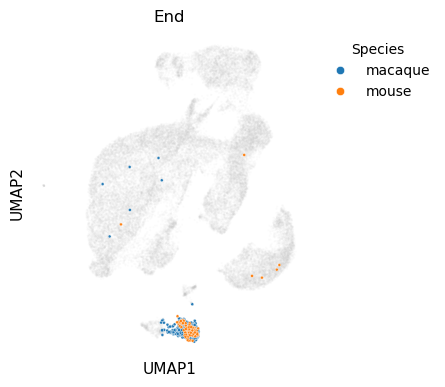

/home/nkefk/miniconda3/envs/muse-dev/lib/python3.10/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/nkefk/miniconda3/envs/muse-dev/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/nkefk/miniconda3/envs/muse-dev/lib/python3.10/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/nkefk/miniconda3/envs/muse-dev/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


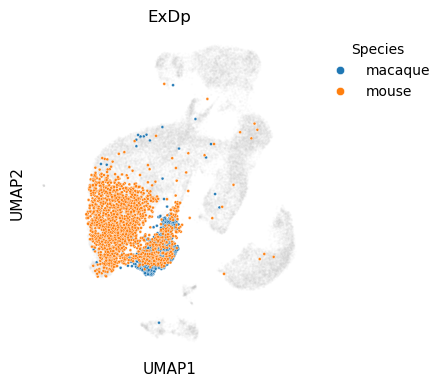

/home/nkefk/miniconda3/envs/muse-dev/lib/python3.10/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/nkefk/miniconda3/envs/muse-dev/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/nkefk/miniconda3/envs/muse-dev/lib/python3.10/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/nkefk/miniconda3/envs/muse-dev/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


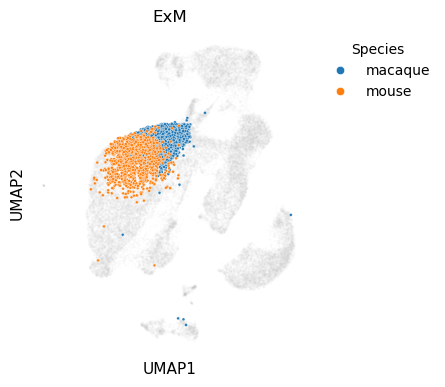

/home/nkefk/miniconda3/envs/muse-dev/lib/python3.10/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/nkefk/miniconda3/envs/muse-dev/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/nkefk/miniconda3/envs/muse-dev/lib/python3.10/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/nkefk/miniconda3/envs/muse-dev/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


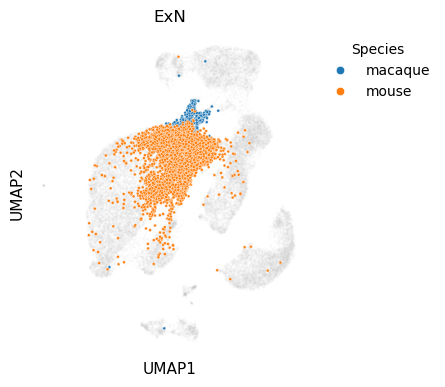

/home/nkefk/miniconda3/envs/muse-dev/lib/python3.10/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/nkefk/miniconda3/envs/muse-dev/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/nkefk/miniconda3/envs/muse-dev/lib/python3.10/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/nkefk/miniconda3/envs/muse-dev/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


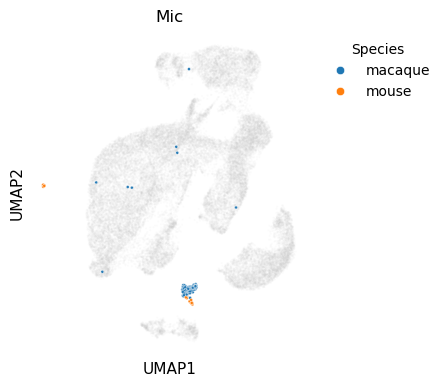

/home/nkefk/miniconda3/envs/muse-dev/lib/python3.10/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/nkefk/miniconda3/envs/muse-dev/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/nkefk/miniconda3/envs/muse-dev/lib/python3.10/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/nkefk/miniconda3/envs/muse-dev/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


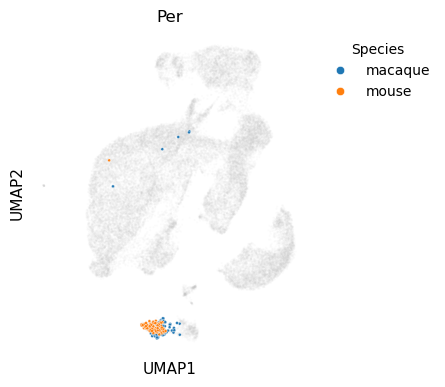

/home/nkefk/miniconda3/envs/muse-dev/lib/python3.10/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/nkefk/miniconda3/envs/muse-dev/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/nkefk/miniconda3/envs/muse-dev/lib/python3.10/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/nkefk/miniconda3/envs/muse-dev/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


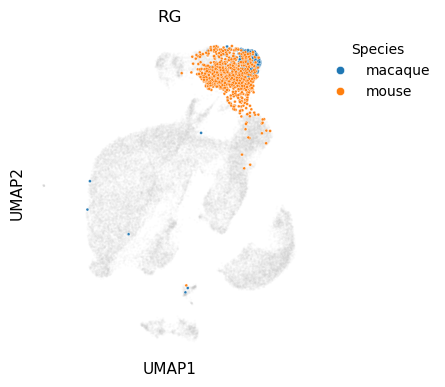

/home/nkefk/miniconda3/envs/muse-dev/lib/python3.10/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/nkefk/miniconda3/envs/muse-dev/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/nkefk/miniconda3/envs/muse-dev/lib/python3.10/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/nkefk/miniconda3/envs/muse-dev/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


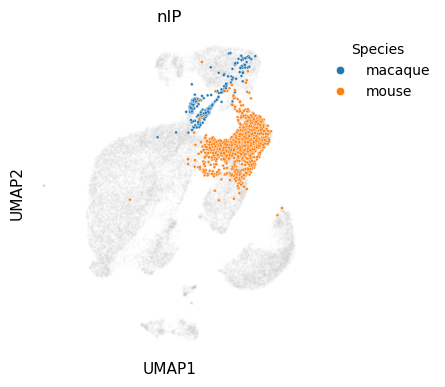

In [12]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scanpy as sc

# =========================
# Paper-style matplotlib settings
# =========================
mpl.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "legend.title_fontsize": 10,
})

# Cell types to highlight (kept as in the original code)
target_celltypes = ['Cycling', 'End', 'ExDp', 'ExM',  'ExN', 'Mic', 'Per', 'RG', 'nIP']

# Work on a copy to avoid chained assignment / view warnings
adata = all_combined.copy()
adata.obs_names_make_unique()
adata.obs.index = adata.obs.index.astype(str)

# Species list (preserve the existing order in the AnnData)
species_list = adata.obs["species"].unique()

# Recompute neighbors/UMAP using the integrated embedding
if "X_muse" not in adata.obsm:
    raise KeyError("adata.obsm['X_muse'] is missing. Please confirm the integrated embedding exists.")

sc.pp.neighbors(adata, use_rep="X_muse", metric="cosine")
sc.tl.umap(adata, random_state=0)

# =========================
# Publication-oriented UMAP styling
# =========================
POINT_SIZE_FG = 18
POINT_SIZE_BG = 8
ALPHA_BG = 0.06
ALPHA_FG = 0.95
EDGE_COLOR = "white"
EDGE_LW = 0.25

# Background (non-highlighted cells)
OUT_COLOR = "#C8C8C8"

# Fixed species colors (tab10)
tab10 = mpl.colormaps["tab10"].colors
species_color = {sp: tab10[i % len(tab10)] for i, sp in enumerate(species_list)}

# =========================
# UMAP highlighting per cell type
# =========================
for ct in target_celltypes:
    # Initialize highlight labels ("Out" for background)
    adata.obs["highlight"] = np.full(adata.n_obs, "Out", dtype=object)

    # Assign labels for the target cell type per species
    found = False
    for sp in species_list:
        mask = (adata.obs["cell_type"] == ct) & (adata.obs["species"] == sp)
        if mask.any():
            adata.obs.loc[mask, "highlight"] = f"{ct} ({sp})"
            found = True

    if not found:
        print(f"Skipping {ct} — no matching cells found.")
        continue

    # Keep only labels that actually exist
    target_labels = [
        f"{ct} ({sp})"
        for sp in species_list
        if f"{ct} ({sp})" in adata.obs["highlight"].unique()
    ]

    # Palette: background + per-species colors
    palette = {"Out": OUT_COLOR}
    for sp in species_list:
        lab = f"{ct} ({sp})"
        if lab in target_labels:
            palette[lab] = species_color[sp]

    fig, ax = plt.subplots(figsize=(4.6, 4.0))

    # Background layer
    out_mask = adata.obs["highlight"] == "Out"
    if out_mask.any():
        sc.pl.umap(
            adata[out_mask].copy(),
            color="highlight",
            palette=palette,
            size=POINT_SIZE_BG,
            alpha=ALPHA_BG,
            zorder=1,
            show=False,
            ax=ax,
        )

    # Foreground (highlighted cells)
    fg_mask = adata.obs["highlight"].isin(target_labels)
    if fg_mask.any():
        sc.pl.umap(
            adata[fg_mask].copy(),
            color="highlight",
            palette=palette,
            size=POINT_SIZE_FG,
            alpha=ALPHA_FG,
            zorder=2,
            show=False,
            ax=ax,
            edgecolor=EDGE_COLOR,
            linewidth=EDGE_LW,
        )

    # Minimal axes for figure panels
    ax.set_title(ct, pad=6)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Legend showing species only
    legend_handles = []
    for sp in species_list:
        lab = f"{ct} ({sp})"
        if lab in palette:
            legend_handles.append(
                plt.Line2D(
                    [0], [0],
                    marker="o",
                    linestyle="",
                    label=sp,
                    markerfacecolor=palette[lab],
                    markeredgecolor=EDGE_COLOR,
                    markeredgewidth=0.4,
                    markersize=6,
                )
            )

    ax.legend(
        handles=legend_handles,
        title="Species",
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
    )

    plt.tight_layout()
    plt.show()